# How to make a Multipanel Plot in Matplotlib

**During my time in undergraduate studies, I consistently found myself having to look to multiple sources to get all the information I needed to make, label, and save a multipanel matplotlib chart. In this tutorial, I walk through how to generate each panel indepedently and then finally combine all of them. All the data needed for generating the plots can be found in the global greenhouse emmissions folder. This tutorial can be cloned and all code should immediately be able to run.**

In [1]:
import pandas as pd #import pandas for data loading and manipulation
import matplotlib.pyplot as plt #import matplotlib for plotting 
import numpy as np #for some math and rounding uses

## Part 1: Line Graph

**The first chart that is generated in this tutorial is a line graph of the five largest greenhouse gas emitters by percentage of total greenhouse gas emmisions from 1970 to 2023. The choice to display this data as a line graph makes sense due to the time dependency of the data, and in this case the graph is being used to show the differences between high emmitting countries over time.**

### Data Loading and Cleaning

**The data has to be cleaned to get the totals we need for the five countries. The data is loaded in and then cycled through to get proper year tags and to determine the top 5 emmiting countries. Finally we get the sums for each country for each year.**

In [3]:
GHG=pd.read_excel('global_greenhouse_emissions/EDGAR_AR5_GHG_1970_2023.xlsx',sheet_name='TOTALS BY COUNTRY',skiprows=9)# load in the data 

year_cols=GHG.columns[4:] #Get the name of all of the year columns
year_cols=year_cols[1:]
year_sums=[] #Cylce through to get year sums to calculate percentages
for i in year_cols:
    sum=GHG[i].sum()
    year_sums.append(sum)

GHG=GHG.sort_values(by='Y_2023')
top_5=GHG['Name'][218:223] #Get top five emmiting countries
top_5_indexes=top_5.index.to_list()

top_5_sums=[]#Get the sums for the top five emmitting countries
for i in year_cols:
    sum=0
    for j in top_5_indexes:
        sum=sum+GHG[i][j]
    top_5_sums.append(sum)
years=[] #clean up year labels
for i in range(1970,2024):
    years.append(i)

### Generating the Plot

**After the data has been all cleaned the line graph can be implemented. For each chart the lines are plotted with their own plot function and then get one x/y label and title. The label for each country must be included in the plot function to appear in the index. In this case to differentiate the different lines by color and then generate a legend, without this information it's much harder for a viewer to understand the chart. The optional arguement 'labels' allows for this in the graph. It is also important to indicate that these are percents of the global total and not just percent out of the top 5 emittors.**

*Note: This section may through an error due to the use of iloc.*

/var/folders/bl/y71_xgtj623_x1nqwy3lq8tr0000gn/T/ipykernel_90184/1455809141.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(years,(GHG.loc[top_5_indexes[0]].iloc[5:])/year_sums,label=GHG.loc[top_5_indexes[0]][3])#plot each line with an individual function
/var/folders/bl/y71_xgtj623_x1nqwy3lq8tr0000gn/T/ipykernel_90184/1455809141.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(years,(GHG.loc[top_5_indexes[1]].iloc[5:])/year_sums,label=GHG.loc[top_5_indexes[1]][3])
/var/folders/bl/y71_xgtj623_x1nqwy3lq8tr0000gn/T/ipykernel_90184/1455809141.py:3: FutureWarning: Series.__getitem__ treating keys

Text(0.5, 1.0, "Top 5 Emitting Countries' Emmisions as a Percent of Global Total")

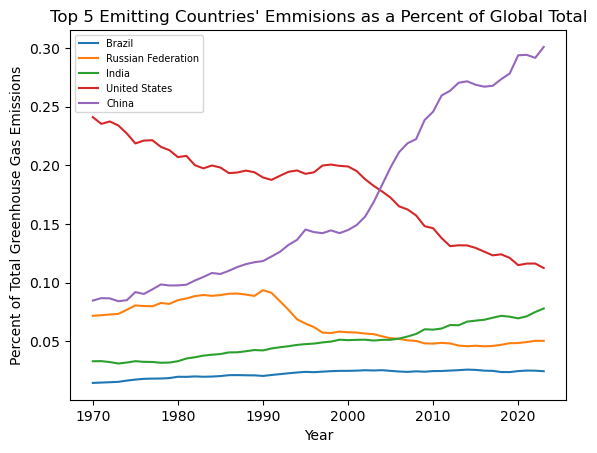

In [49]:
plt.plot(years,(GHG.loc[top_5_indexes[0]].iloc[5:])/year_sums,label=GHG.loc[top_5_indexes[0]][3])#plot each line with an individual function
plt.plot(years,(GHG.loc[top_5_indexes[1]].iloc[5:])/year_sums,label=GHG.loc[top_5_indexes[1]][3])
plt.plot(years,(GHG.loc[top_5_indexes[2]].iloc[5:])/year_sums,label=GHG.loc[top_5_indexes[2]][3])
plt.plot(years,(GHG.loc[top_5_indexes[3]].iloc[5:])/year_sums,label=GHG.loc[top_5_indexes[3]][3])
plt.plot(years,(GHG.loc[top_5_indexes[4]].iloc[5:])/year_sums,label=GHG.loc[top_5_indexes[4]][3])
plt.legend(fontsize=7)#used to display the legend, so each line is labled 
plt.ylabel('Percent of Total Greenhouse Gas Emissions')#set y-axis label
plt.xlabel('Year')#set x-axis label
plt.title("Top 5 Emitting Countries' Emmisions as a Percent of Global Total")#set title
#if you want to save just this figure uncomment this line:
#plt.savefig('emmisions_line_graph.png');

## Part 2: Histogram

**The second graph generated for the multipanel plot is a distribution of greenhouse gas emissions for the year 2023. This plot is easy as their is no data cleaning nessecary, and the matplotlib architecture is nice for generating the plot. In this case because the data being displayed is a distribution of emmisions by country. A histogram allows a viewer to see this distribution and the skew. In this case optional arguments 'bins'and 'edgecolor' are used. Bins determines the number of bars or spots. In this case 20 is used because for this data is allows for a somewhat smooth distribution while still showing spikes in the distribution. Edgecolor is used simply because it makes it easier to see the bars. For the labeling on this chart, it is important to ensure that it is clear to the viewer what they are seeing. So, label is with global distribution and axis labels indicating what it is a distribution of.**

In [7]:
GHG['Y_2023']

198    1.072592e+00
152    1.233511e+00
148    1.522120e+00
127    2.666962e+00
133    2.883918e+00
           ...     
93     4.133554e+06
211    5.960804e+06
37     1.594399e+07
145             NaN
157             NaN
Name: Y_2023, Length: 225, dtype: float64

Text(0, 0.5, 'Number of Countries')

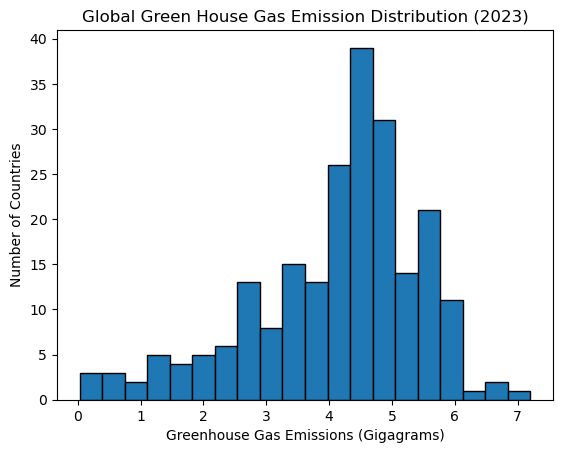

In [53]:
plt.hist(np.log10(GHG['Y_2023']),bins=20,edgecolor='black')#generate histogram
plt.title('Global Green House Gas Emission Distribution (2023)')#set title
plt.xlabel('Greenhouse Gas Emissions (Gigagrams)')
plt.ylabel('Number of Countries')
#if you want to save just this figure uncomment this line:
#plt.savefig('emmisions_histogram.png');

## Part 3: Stacked Line Graph

**In the next section, the tutorial will generate a stacked line graph showing the total greenhouse gas emisions overtime as well as the portion each of the main three emision gases make of that total. This style is graphic is used here because it is specfically good at showing the total amount of something over time but also the proportions of things that make it up. Some data cleaning is required for this graphic, and all data can be found in the github repository.**

### Data Loading and Cleaning

**In this case data for each kind of case has to be pulled seperately. Then I have to get the totals for each year as the data is broken down by country. Finally all of the data has to be adjusted as some gases have more of a greenhouse gas effect. This is why N2O numbers are multiplied by 265 and CH4 numbers are multiplied by 28. All data is contain in the global greenhouse emissions folder.**

In [11]:
n2o=pd.read_excel('global_greenhouse_emissions/EDGAR_N2O_1970_2023.xlsx',skiprows=9,sheet_name='TOTALS BY COUNTRY')#load in N2O data
co2=pd.read_excel('global_greenhouse_emissions/IEA_EDGAR_CO2_1970_2023.xlsx',skiprows=9,sheet_name='TOTALS BY COUNTRY')#load in CO2 data
ch4=pd.read_excel('global_greenhouse_emissions/EDGAR_CH4_1970_2023.xlsx',skiprows=9,sheet_name='TOTALS BY COUNTRY')#load in CH4 data

In [13]:
n2o_adj_tots_years=[]
for i in year_cols: #cycle through and get data for each year for N2O 
    sum=n2o[i].sum()
    n2o_adj_tots_years.append(sum*265)#adjust numbers
co2_tots_years=[]
for i in year_cols:#cycle through and get data for each year for CO2
    sum=co2[i].sum()
    co2_tots_years.append(sum)
ch4_adj_tots_years=[]
for i in year_cols:#cycle through and get data for each year for CH$ 
    sum=ch4[i].sum()
    ch4_adj_tots_years.append(sum*28)#adjust numbers

### Generating the Plot

**The most important thing to remember with a stacked plot is to ensure that data is in the right order. This case most effect to least effect. This is why the data is given with CO2 first, then CH4, and finaly N2O. In this code, the optional argument labels is used. This is simply so that each chunk can be associated with a specific greenhouse gas, allowing viewers to visually see which greenhouse gas makes up the most or least portion of emisions. In this chart as with previous charts ensure that it indicates this is global proportions and not specific to one country.**

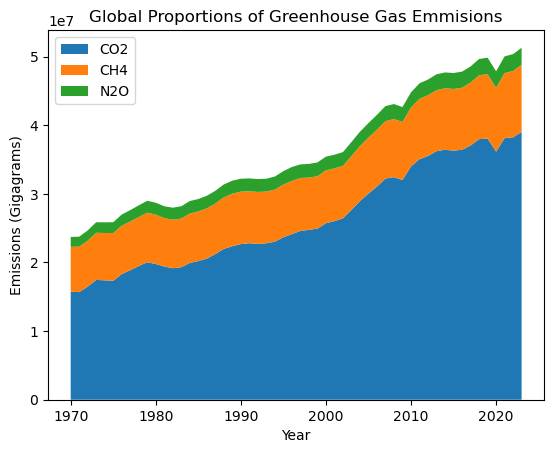

In [55]:
plt.stackplot(years,co2_tots_years,ch4_adj_tots_years,n2o_adj_tots_years,labels=['CO2','CH4','N2O'])#generate plot
plt.xlabel('Year')#set x-label
plt.ylabel('Emissions (Gigagrams)')#set y-label
plt.title('Global Proportions of Greenhouse Gas Emmisions')#set title
plt.legend(loc='upper left')#indicate that there needs to be a legend 
#if you want to save just this figure uncomment this line:
#plt.savefig('emmisions_stackplot.png');

## Part 4 Donut Chart

**This is the final chart of the four panels that make up the multipanel chart. This final part is a donut chart of the different sectors that produce greenhouse gas emissions in the United States.**

### Data Loading and Cleaning

**This graphic requires a little bit more data loading and cleaning. The data requires similar cycling as has been to the previous datasets used. It also requires cycling through to break apart codes. It also requires that it be broken down to just be data for the United States. In this case, the US is focused on because it is a top emmitor and also a country that has somewhat succesfully reduced emmisions in recent deacades.**

*Note: Note this data may through an error due to the setting of the codes column*

In [23]:
GHG_broken_down=pd.read_excel('global_greenhouse_emissions/EDGAR_AR5_GHG_1970_2023.xlsx',sheet_name='IPCC 2006',skiprows=9)#load in data
GHG_broken_down_US=GHG_broken_down[GHG_broken_down['Country_code_A3']=='USA']#subset it to just US data

In [24]:
total_GHGs_by_year=[]
for i in year_cols:#cylce through to get sums 
    sum=GHG_broken_down_US[i].sum()
    total_GHGs_by_year.append(sum)

codes=[]
for i in GHG_broken_down_US['ipcc_code_2006_for_standard_report']:
    codes.append(int(i[0]))

GHG_broken_down_US['codes']=codes

/var/folders/bl/y71_xgtj623_x1nqwy3lq8tr0000gn/T/ipykernel_90184/1526941634.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  GHG_broken_down_US['codes']=codes


### Generating the Plot

**A donut chart is used to display this data becuase it gives viewers an area based way to see the proportions. It can also be good at, as in this case, showing when one proportion or area is especially large. One of the most important things to do when generating a donut chart is to make sure that everything is labeled properly. Oftentimes the human eyes struggles to truly see the proportions represented in the chart so labels can help alleviate that issue. In this case optional arguments, labels, autopct, wedgeprops, and textprops are used. Labels provides the appropriate labels for each slice. Autopct give the basic formating for the percent labels of each slice. Wedgeprops gets a based a dictionary of properties for the wedges in the chart, in this casse width is set to .4 to generat a donut chart if it has been 1 then we would get a pie chart. Wedgeprops is important as you want to ensure that the labels for the data do not overlap the donut. Make sure the donut is thin enough that all labels are clear. Textprops is used simply to pass the text size for the labels so that they can be easily seen.**

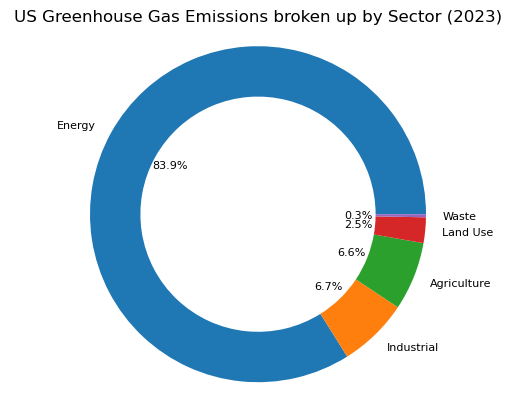

In [29]:
sizes=GHG_broken_down_US.groupby('codes')['Y_2023'].sum()/total_GHGs_by_year[len(total_GHGs_by_year)-1]#generate sizes
fig, ax = plt.subplots()
ax.pie(sizes, 
       frame=False,labels=['Energy','Industrial','Agriculture','Land Use','Waste'],autopct='%1.1f%%',wedgeprops={'width': .3},
       textprops={'fontsize':8})#generate plot
ax.axis('equal')
plt.title('US Greenhouse Gas Emissions broken up by Sector (2023)')#set title
plt.show()#show plot
#if you want to save just this figure uncomment this line:
#plt.savefig('emmisions_donut_chart.png');

## Part 5 Multipanel Plot

**The last step in finalizing this multipanel plot is to put all the graphs together. By putting all of the graphics together you allow a viewer to get a more full understanding of the effects and causes of greenhouse gases. The main thing to remember when going through the code in this portion is that each plot needs to have a plt.subplot line before it. This tells matplotlib which panel you want the graph to go in. A line of plt.subplot(2,2,1) tells matplotlib make a 2 by 2 figure and the next generated plot should be the first panel. Also, when generating a multipanel plot labels are vital. Viewers may become easily confused or misguided if a plot does not have clear or big enough axis labels and titles. Ensure that there isn't overlap and that all details are visible.**

*Note: This code may throw an error due to the use of iloc*

/var/folders/bl/y71_xgtj623_x1nqwy3lq8tr0000gn/T/ipykernel_90184/571464612.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(years,(GHG.loc[top_5_indexes[0]].iloc[5:])/year_sums,label=GHG.loc[top_5_indexes[0]][3])
/var/folders/bl/y71_xgtj623_x1nqwy3lq8tr0000gn/T/ipykernel_90184/571464612.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(years,(GHG.loc[top_5_indexes[1]].iloc[5:])/year_sums,label=GHG.loc[top_5_indexes[1]][3])
/var/folders/bl/y71_xgtj623_x1nqwy3lq8tr0000gn/T/ipykernel_90184/571464612.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future versi

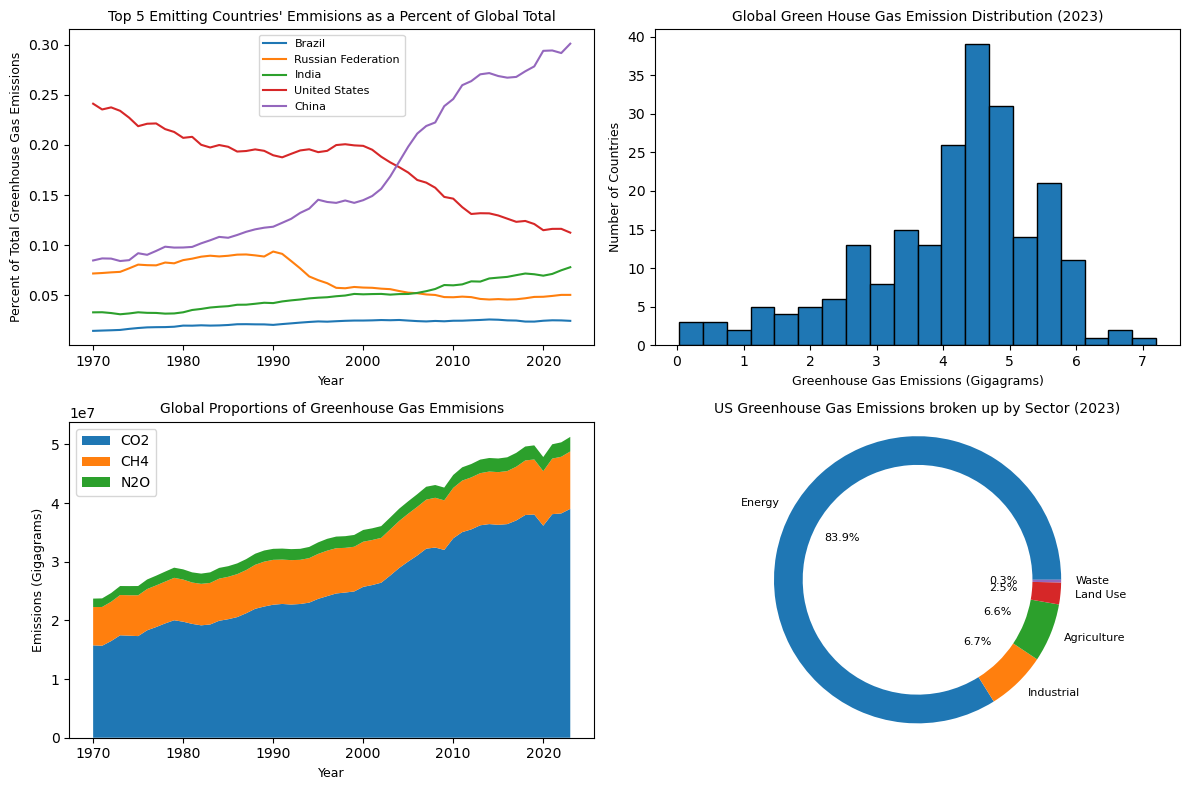

In [86]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)#subplot location for chart one
#all of this code is the same as above for generating the line chart:
plt.plot(years,(GHG.loc[top_5_indexes[0]].iloc[5:])/year_sums,label=GHG.loc[top_5_indexes[0]][3])
plt.plot(years,(GHG.loc[top_5_indexes[1]].iloc[5:])/year_sums,label=GHG.loc[top_5_indexes[1]][3])
plt.plot(years,(GHG.loc[top_5_indexes[2]].iloc[5:])/year_sums,label=GHG.loc[top_5_indexes[2]][3])
plt.plot(years,(GHG.loc[top_5_indexes[3]].iloc[5:])/year_sums,label=GHG.loc[top_5_indexes[3]][3])
plt.plot(years,(GHG.loc[top_5_indexes[4]].iloc[5:])/year_sums,label=GHG.loc[top_5_indexes[4]][3])
plt.legend(fontsize=8, loc='upper center')
plt.ylabel('Percent of Total Greenhouse Gas Emissions',fontsize=9)
plt.xlabel('Year',fontsize=9)
plt.title("Top 5 Emitting Countries' Emmisions as a Percent of Global Total",fontsize=10)

plt.subplot(2, 2, 2)#subplot location for chart two
#all of this code is the same as above for generating the histogram:
plt.hist(np.log10(GHG['Y_2023']),bins=20,edgecolor='black')
plt.title('Global Green House Gas Emission Distribution (2023)',fontsize=10)
plt.xlabel('Greenhouse Gas Emissions (Gigagrams)',fontsize=9)
plt.ylabel('Number of Countries',fontsize=9)

plt.subplot(2, 2, 3)#subplot location for chart three
#all of this code is the same as above for genreating the stackplot
plt.stackplot(years,co2_tots_years,ch4_adj_tots_years,n2o_adj_tots_years,labels=['CO2','CH4','N2O'])
plt.xlabel('Year',fontsize=9)
plt.ylabel('Emissions (Gigagrams)',fontsize=9)
plt.title('Global Proportions of Greenhouse Gas Emmisions',fontsize=10)
plt.legend(loc='upper left', fontsize=10)

plt.subplot(2, 2, 4)#subplot location for chart four
#all of this code is the same as above for generating the donut chart
plt.pie(sizes, 
       frame=False,labels=['Energy','Industrial','Agriculture','Land Use','Waste'],autopct='%1.1f%%',wedgeprops={'width': 0.2},
        textprops={'fontsize':8})
plt.axis('equal')
plt.title('US Greenhouse Gas Emissions broken up by Sector (2023)',fontsize=10)

plt.tight_layout()#set tight layout so that everything fits nicely into one visualization 

#if you want to save just this figure uncomment this line:
#plt.savefig('emmisions_multipanel.png');

**That's it! After running this code you should be left with a four panel plot containing a line chart, histogram, stackplot, and donut chart!**